# Deep Learning Assignment # 01

### 1. Load necessary libraries

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import krippendorff
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import random


### 2. Path Definitions

In [8]:
image_dir = r"C:\Users\dilaw\Downloads\Dataset\Dataset\images"
annotation_dir = r"C:\Users\dilaw\Downloads\Dataset\Dataset\annotations"


### 3. Load Annotations
1. Filter files by endings (_exp.ny, _val.npy, _aro.npy) and sort them for consistent ordering
2. Concatenate arrays for expressions (0-7), valence, and arousal

In [9]:
def load_annotations(annotation_dir=annotation_dir):
    exp_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('_exp.npy')])
    val_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('_val.npy')])
    aro_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith('_aro.npy')])

    expressions, valence, arousal = [], [], []

    for f in exp_files:
        expressions.append(np.atleast_1d(np.load(os.path.join(annotation_dir, f))))
    for f in val_files:
        valence.append(np.atleast_1d(np.load(os.path.join(annotation_dir, f))))
    for f in aro_files:
        arousal.append(np.atleast_1d(np.load(os.path.join(annotation_dir, f))))

    return np.concatenate(expressions), np.concatenate(valence), np.concatenate(arousal)


### 4. Load Images
The images are also normalized here

In [10]:
def load_images(image_paths):
    images = []
    for path in image_paths:
        img = load_img(os.path.join(image_dir, path), target_size=(224, 224))
        img = img_to_array(img) / 255.0
        images.append(img)
    return np.array(images, dtype=np.float32)


### 5. Metric Functions
1. CCC: combines pearson correlation with mean squared difference, measuring agreement between predicted and true values
2. Sign agreement metric: calculates the proportion of predictions with the correct sign (+,-), penalizing incorrect signs

Both are used for valence and arousal predictions

In [11]:
def concordance_correlation_coefficient(y_true, y_pred):
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    return (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2)


In [12]:
def sign_agreement_metric(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


### 6. Evaluation Metrics
Calculates multiple classification and regression metrics:
1. Classification: accuracy, F1-score, Cohen’s kappa, Krippendorff’s alpha, AUC-ROC, AUC-PR.
2. Regression: RMSE, Pearson correlation, sign agreement metric concordance correlation coefficient.

In [13]:
def evaluate_model(y_true_exp, y_pred_exp, y_true_val, y_pred_val, y_true_aro, y_pred_aro):
    """Calculates evaluation metrics for classification and regression."""
    results = {}

    # Classification metrics
    y_pred_exp_labels = np.argmax(y_pred_exp, axis=1)
    y_true_exp_labels = y_true_exp

    results['accuracy'] = accuracy_score(y_true_exp_labels, y_pred_exp_labels)
    results['f1_score'] = f1_score(y_true_exp_labels, y_pred_exp_labels, average='weighted')
    results['cohen_kappa'] = cohen_kappa_score(y_true_exp_labels, y_pred_exp_labels)
    results['krippendorff_alpha'] = krippendorff.alpha(np.vstack((y_true_exp_labels, y_pred_exp_labels)))

    y_true_bin = label_binarize(y_true_exp_labels, classes=range(8))
    results['auc_roc'] = roc_auc_score(y_true_bin, y_pred_exp, multi_class='ovr')
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_exp.ravel())
    results['auc_pr'] = auc(recall, precision)

    # Regression metrics
    results['valence_rmse'] = np.sqrt(np.mean((y_true_val - y_pred_val) ** 2))
    results['valence_corr'], _ = pearsonr(y_true_val, y_pred_val)
    results['valence_sagr'] = sign_agreement_metric(y_true_val, y_pred_val)
    results['valence_ccc'] = concordance_correlation_coefficient(y_true_val, y_pred_val)

    results['arousal_rmse'] = np.sqrt(np.mean((y_true_aro - y_pred_aro) ** 2))
    results['arousal_corr'], _ = pearsonr(y_true_aro, y_pred_aro)
    results['arousal_sagr'] = sign_agreement_metric(y_true_aro, y_pred_aro)
    results['arousal_ccc'] = concordance_correlation_coefficient(y_true_aro, y_pred_aro)

    return results


### 7. Facial Expression Model Class
Uses a pre-trained CNN base (MobileNetV2 or DenseNet121) for feature extraction.
Adds:
1. GlobalAveragePooling → reduces spatial dimensions.
2. Dense layer (512 units) with ReLU.
3. Dropout layer → regularization to prevent overfitting.
4. Output heads for expression classification, valence, and arousal regression.

Compiles model with:
1. Loss functions: sparse categorical crossentropy for classification, MSE for regression.
2. Metrics: accuracy for classification, MSE for regression.

Plots accuracy and loss curves for training and validation.

Runs predictions and evaluates using the custom evaluation function.

In [14]:
class FacialExpressionModel:
    def __init__(self, base_model_name, num_classes=8):
        self.base_model_name = base_model_name
        self.num_classes = num_classes
        self.model = None
        self.history = None

    def build_model(self, input_shape=(224, 224, 3)):
        """Build CNN model with classification and regression heads."""
        if self.base_model_name == "MobileNetV2":
            base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=input_shape)
        elif self.base_model_name == "DenseNet121":
            base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=input_shape)
        else:
            raise ValueError("Unknown model name")

        for layer in base_model.layers:
            layer.trainable = False  # Freeze layers for transfer learning

        x = GlobalAveragePooling2D()(base_model.output)
        x = Dense(512, activation="relu")(x)
        x = Dropout(0.5)(x)

        expression_output = Dense(self.num_classes, activation="softmax", name="expression")(x)
        valence_output = Dense(1, activation="tanh", name="valence")(x)
        arousal_output = Dense(1, activation="tanh", name="arousal")(x)

        self.model = Model(inputs=base_model.input, outputs=[expression_output, valence_output, arousal_output])

    def compile_model(self):
        self.model.compile(
            optimizer="adam",
            loss={
                "expression": "sparse_categorical_crossentropy",
                "valence": "mse",
                "arousal": "mse"
            },
            metrics={
                "expression": ["accuracy"],
                "valence": ["mse"],
                "arousal": ["mse"]
            }
        )

    def train_model(self, train_images, train_labels, val_images, val_labels, batch_size=32, epochs=20, augment=False):
        if augment:
            datagen = ImageDataGenerator(
                rotation_range=20,
                width_shift_range=0.1,
                height_shift_range=0.1,
                horizontal_flip=True,
                zoom_range=0.2
            )

            def generator():
                while True:
                    for i in range(0, len(train_images), batch_size):
                        batch_imgs = train_images[i:i+batch_size]
                        batch_exp = train_labels[0][i:i+batch_size]
                        batch_val = train_labels[1][i:i+batch_size]
                        batch_aro = train_labels[2][i:i+batch_size]
                        augmented_imgs = next(datagen.flow(batch_imgs, batch_size=len(batch_imgs), shuffle=False))
                        yield augmented_imgs, {"expression": batch_exp, "valence": batch_val, "arousal": batch_aro}

            steps_per_epoch = len(train_images) // batch_size
            self.history = self.model.fit(
                generator(),
                steps_per_epoch=steps_per_epoch,
                validation_data=(val_images, {"expression": val_labels[0], "valence": val_labels[1], "arousal": val_labels[2]}),
                epochs=epochs
            )
        else:
            self.history = self.model.fit(
                train_images,
                {"expression": train_labels[0], "valence": train_labels[1], "arousal": train_labels[2]},
                validation_data=(val_images, {"expression": val_labels[0], "valence": val_labels[1], "arousal": val_labels[2]}),
                epochs=epochs,
                batch_size=batch_size
            )

    def plot_training_graphs(self):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.history.history["expression_accuracy"], label="Train Accuracy")
        plt.plot(self.history.history["val_expression_accuracy"], label="Val Accuracy")
        plt.title(f"{self.base_model_name} Accuracy")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.history.history["loss"], label="Train Loss")
        plt.plot(self.history.history["val_loss"], label="Val Loss")
        plt.title(f"{self.base_model_name} Loss")
        plt.legend()
        plt.show()

    def evaluate(self, test_images, test_labels):
        y_pred_exp, y_pred_val, y_pred_aro = self.model.predict(test_images)
        return evaluate_model(test_labels[0], y_pred_exp, test_labels[1], y_pred_val.ravel(), test_labels[2], y_pred_aro.ravel())

    def qualitative_results(self, images, labels, n_samples=5):
        y_pred_exp, _, _ = self.model.predict(images)
        y_pred_labels = np.argmax(y_pred_exp, axis=1)
        correct_idx = np.where(y_pred_labels == labels[0])[0]
        incorrect_idx = np.where(y_pred_labels != labels[0])[0]

        plt.figure(figsize=(12, 6))
        for i, idx in enumerate(random.sample(list(correct_idx), min(n_samples, len(correct_idx)))):
            plt.subplot(2, n_samples, i + 1)
            plt.imshow(images[idx])
            plt.title(f"Correct: {labels[0][idx]}")
            plt.axis("off")

        for i, idx in enumerate(random.sample(list(incorrect_idx), min(n_samples, len(incorrect_idx)))):
            plt.subplot(2, n_samples, n_samples + i + 1)
            plt.imshow(images[idx])
            plt.title(f"Pred: {y_pred_labels[idx]}, True: {labels[0][idx]}")
            plt.axis("off")
        plt.show()


### 8. Main Function
Steps:
1. Load annotations and image paths.
2. Filter invalid data where valence/arousal = -2.
3. Split dataset into training, validation, and test sets.
4. Load images for each set.
5. Initialize and train models (MobileNetV2, DenseNet121).
6. Evaluate models and store results.
7. Plot qualitative results.
8. Print performance table.


--- Training MobileNetV2 ---
Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 73s 741ms/step - arousal_mse: 0.4495 - expression_accuracy: 0.1172 - loss: 3.4093 - valence_mse: 0.4794 - val_arousal_mse: 0.1474 - val_expression_accuracy: 0.1219 - val_loss: 2.4508 - val_valence_mse: 0.2128
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 70s 814ms/step - arousal_mse: 0.1610 - expression_accuracy: 0.1462 - loss: 2.4781 - valence_mse: 0.2313 - val_arousal_mse: 0.1541 - val_expression_accuracy: 0.1269 - val_loss: 2.4583 - val_valence_mse: 0.2173
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 71s 818ms/step - arousal_mse: 0.1643 - expression_accuracy: 0.1300 - loss: 2.4775 - valence_mse: 0.2301 - val_arousal_mse: 0.1434 - val_expression_accuracy: 0.1256 - val_loss: 2.4391 - val_valence_mse: 0.2109
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 70s 811ms/step - arousal_mse: 0.1571 - expression_accuracy: 0.1296 - loss: 2.4717 - valence_mse: 0.2303 - val_arousal_mse: 0.1404 - val_expression_accuracy: 0.1194 - val_loss: 2.4413 - val_va

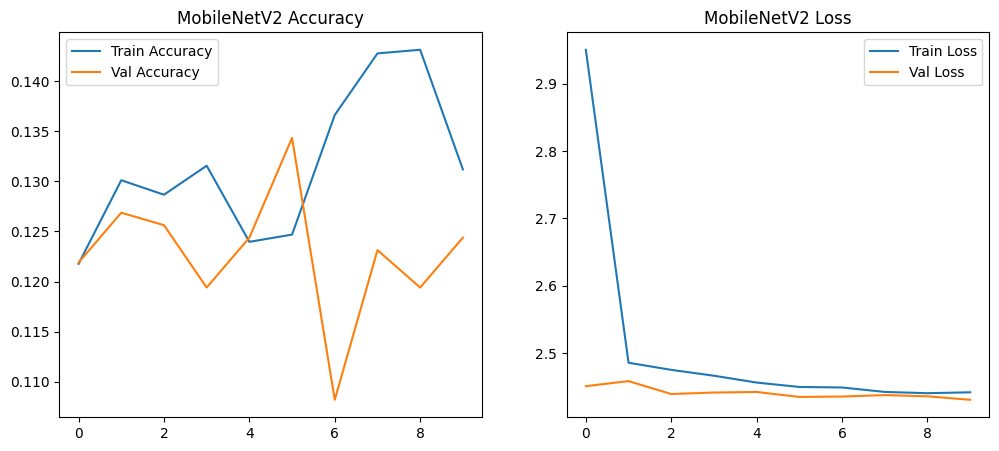

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 562ms/step
Results for MobileNetV2: {'accuracy': 0.10101010101010101, 'f1_score': 0.0652854168101513, 'cohen_kappa': -0.018870379069851673, 'krippendorff_alpha': -0.14008725904191088, 'auc_roc': 0.4732388449236397, 'auc_pr': 0.11557920766605818, 'valence_rmse': 0.46622717, 'valence_corr': -0.02423191762045107, 'valence_sagr': 0.7070707070707071, 'valence_ccc': -0.0020517215985612017, 'arousal_rmse': 0.3957428, 'arousal_corr': -0.06774724126409236, 'arousal_sagr': 0.7474747474747475, 'arousal_ccc': -0.007234007930273873}
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 477ms/step


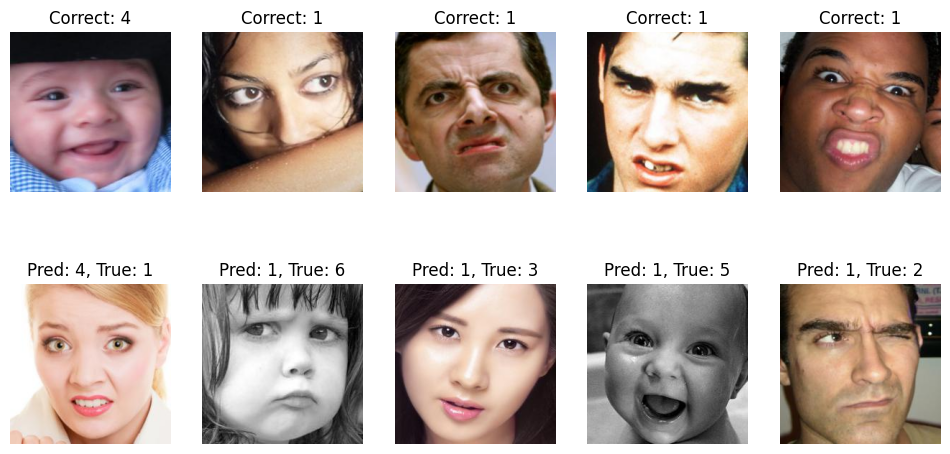


--- Training DenseNet121 ---
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - arousal_mse: 0.5019 - expression_accuracy: 0.1293 - loss: 3.3935 - valence_mse: 0.5015 - val_arousal_mse: 0.1428 - val_expression_accuracy: 0.0908 - val_loss: 2.4594 - val_valence_mse: 0.2260
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 297s 3s/step - arousal_mse: 0.1592 - expression_accuracy: 0.1276 - loss: 2.4793 - valence_mse: 0.2352 - val_arousal_mse: 0.1424 - val_expression_accuracy: 0.1306 - val_loss: 2.4439 - val_valence_mse: 0.2164
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - arousal_mse: 0.1524 - expression_accuracy: 0.1159 - loss: 2.4621 - valence_mse: 0.2307 - val_arousal_mse: 0.1404 - val_expression_accuracy: 0.1119 - val_loss: 2.4511 - val_valence_mse: 0.2150
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - arousal_mse: 0.1539 - expression_accuracy: 0.1502 - loss: 2.4629 - valence_mse: 0.2283 - val_arousal_mse: 0.1393 - val_expression_a

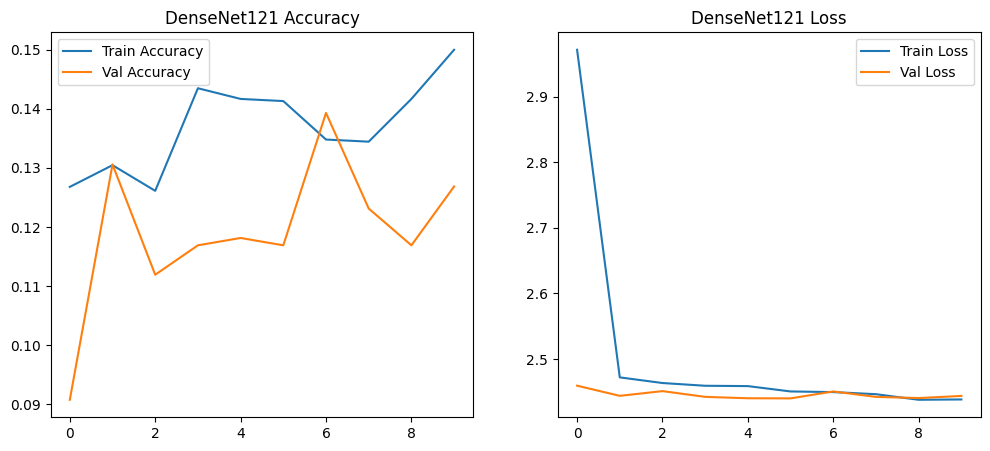

13/13 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step
Results for DenseNet121: {'accuracy': 0.12121212121212122, 'f1_score': 0.08598983957210998, 'cohen_kappa': 0.0017674499463969928, 'krippendorff_alpha': -0.09523862371573144, 'auc_roc': 0.46743194125126875, 'auc_pr': 0.11379158380244185, 'valence_rmse': 0.46588114, 'valence_corr': 0.02932966455257245, 'valence_sagr': 0.7070707070707071, 'valence_ccc': 0.0037431204453003903, 'arousal_rmse': 0.39929795, 'arousal_corr': -0.11245100951566699, 'arousal_sagr': 0.7474747474747475, 'arousal_ccc': -0.020172430541481674}
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step


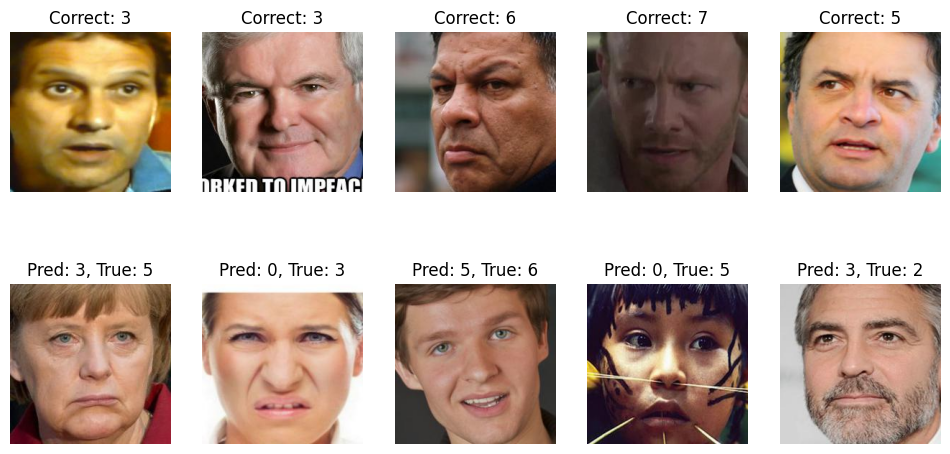


Final Results Comparison:
                    MobileNetV2  DenseNet121
accuracy               0.101010     0.121212
f1_score               0.065285     0.085990
cohen_kappa           -0.018870     0.001767
krippendorff_alpha    -0.140087    -0.095239
auc_roc                0.473239     0.467432
auc_pr                 0.115579     0.113792
valence_rmse           0.466227     0.465881
valence_corr          -0.024232     0.029330
valence_sagr           0.707071     0.707071
valence_ccc           -0.002052     0.003743
arousal_rmse           0.395743     0.399298
arousal_corr          -0.067747    -0.112451
arousal_sagr           0.747475     0.747475
arousal_ccc           -0.007234    -0.020172


In [ ]:
def main():
    # Load data
    expressions, valence, arousal = load_annotations()
    image_paths = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png"))]

    valid_idx = (valence != -2) & (arousal != -2)
    expressions = expressions[valid_idx]
    valence = valence[valid_idx]
    arousal = arousal[valid_idx]
    image_paths = np.array(image_paths)[valid_idx]

    # Split into train, val, test
    X_train, X_temp, y_train_exp, y_temp_exp, y_train_val, y_temp_val, y_train_aro, y_temp_aro = train_test_split(
        image_paths, expressions, valence, arousal, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val_exp, y_test_exp, y_val_val, y_test_val, y_val_aro, y_test_aro = train_test_split(
        X_temp, y_temp_exp, y_temp_val, y_temp_aro, test_size=0.33, random_state=42
    )

    X_train_images = load_images(X_train)
    X_val_images = load_images(X_val)
    X_test_images = load_images(X_test)

    y_train_exp, y_val_exp, y_test_exp = y_train_exp.astype(np.int32), y_val_exp.astype(np.int32), y_test_exp.astype(np.int32)
    y_train_val, y_val_val, y_test_val = y_train_val.astype(np.float32), y_val_val.astype(np.float32), y_test_val.astype(np.float32)
    y_train_aro, y_val_aro, y_test_aro = y_train_aro.astype(np.float32), y_val_aro.astype(np.float32), y_test_aro.astype(np.float32)

    train_labels = [y_train_exp, y_train_val, y_train_aro]
    val_labels = [y_val_exp, y_val_val, y_val_aro]
    test_labels = [y_test_exp, y_test_val, y_test_aro]

    models = ["MobileNetV2", "DenseNet121"]

    all_results = {}

    for model_name in models:
        print(f"\n--- Training {model_name} ---")
        fem = FacialExpressionModel(model_name)
        fem.build_model()
        fem.compile_model()
        fem.train_model(X_train_images, train_labels,
                        X_val_images, val_labels,
                        epochs=10, augment=True)

        fem.plot_training_graphs()

        results = fem.evaluate(X_test_images, (y_test_exp, y_test_val, y_test_aro))
        all_results[model_name] = results

        print(f"Results for {model_name}:", results)
        fem.qualitative_results(X_test_images, (y_test_exp, y_test_val, y_test_aro))

    df_results = pd.DataFrame(all_results)
    print("\nFinal Results Comparison:")
    print(df_results)


if __name__ == "__main__":
    main()
